In [38]:
#%%
import math
import numpy as np
import inspect
import importlib

import scipy.interpolate

import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 16

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.offline import plot
pio.renderers.default = "svg"

import sys
import os
parent_directory = os.path.dirname(os.getcwd())
sys.path.append(parent_directory)
#sys.path.append(os.path.dirname(parent_directory))
#sys.path.append(os.path.dirname(os.path.dirname(parent_directory)))

from IoT_node_models.Energy_model                        import *
from IoT_node_models.Energy_model.Wireless_communication import *
from IoT_node_models.Hardware_Modules                    import *
from IoT_node_models.Analysis                            import *

path_to_save_svg = "Saved_Data"



In [39]:
dictColor = {"DeepBlue"     :"#095256",
             "LightBlue"    :"#01a7c2",
             "UnitedBlue"   :"#6290c8",
             "CerulBlue"    :"#6096ba",
             "Green"        :"#44af69",
             "LightRed"     :"#f8333c",
             "DeepRed"      :"#a22c29",
             "Orange"       :"#fcab10",
             "Sandy"        :"#fc9e4F",
             "Olivine"      :"#9ab87a",
             "CarolinaBlue" :"#009DDC"}
listColor = list(dictColor.values())

In [40]:
MCU_Clock_freq = 20 #MHz

MCU_module = Node_module(name="Apollo3",
                            v      =1.8,
                            i_sleep=0.010)

MCU_state_active  = Module_state("Active",i = 0.045*    MCU_Clock_freq,duration = None)
MCU_state_fftHW   = Module_state("FFT HW",i = (4.3/128)*MCU_Clock_freq,duration = None)

MCU_module.add_state(MCU_state_active)
MCU_module.add_state(MCU_state_fftHW)

In [41]:
DMA_Clock_freq = 20 #MHz

DMA_module = Node_module(name="DMA",
                            v      =1.8,
                            i_sleep=0.00)

DMA_state_active  = Module_state("Active",i = 0.002*DMA_Clock_freq,duration = None)

DMA_module.add_state(DMA_state_active)

In [42]:
Micro_module = Node_module(name="MicroIC",
                            v      =1.8,
                            i_sleep=0.000)

#Micro_state_active  = Module_state("Active",i = 0.2,duration = None)
Micro_state_active  = Module_state("Active",i = 0.06,duration = None)

Micro_module.add_state(Micro_state_active)

In [43]:
TRX_module = Node_module(name="LoRa radio",
                            v=1.8,
                            i_sleep=0)#6e-3)
TRX_state_TX = Module_state("TX",i = 0, duration = None)#52,duration = None)
TRX_state_RX = Module_state("RX",i = 0, duration = None)#22,duration = None)
TRX_module.add_state(TRX_state_TX)
TRX_module.add_state(TRX_state_RX)

In [44]:

module_List = [MCU_module,DMA_module,Micro_module,TRX_module]

In [45]:
fs = 10e3
Samples_p_melvec = 256
N_melvec         = 20
Cycles_p_melvec  = 120000

Melvec_acquisition =  Node_task(  name = "Melvec acquisition", 
                        node_modules= module_List, 
                        subtasks   = [  Node_subtask(name='Acquisition',module=Micro_module,
                                        moduleState = Micro_state_active, stateDuration=Samples_p_melvec/fs),
                                        Node_subtask(name='DMA transfer',module=DMA_module ,
                                        moduleState = DMA_state_active     , stateDuration=(1/10)*Samples_p_melvec/fs),
                                        Node_subtask(name='Processing'  ,module=MCU_module ,
                                        moduleState = MCU_state_active  , stateDuration=Cycles_p_melvec/(MCU_Clock_freq*1e6))], 
                        taskDuration = (Samples_p_melvec/fs), 
                        )

Melvec_aquisition_duration       = (Samples_p_melvec/fs)
Melvec_processing_duration       = Cycles_p_melvec/(MCU_Clock_freq*1e6)
Spectrogram_acquisition_duration = N_melvec * Melvec_aquisition_duration
Spectrogram_per_day              = np.floor(24*60*60 / Spectrogram_acquisition_duration)

if Melvec_aquisition_duration<Melvec_processing_duration:
    raise Exception("Melvec acquisition duration is shorter than processing duration!")

In [46]:
fs = 10e3

# From Thomas Antoine Master thesis
Samples_p_melvec = 512
N_melvec         = 10
                    # 512-pt FFT is 46 % of MFCC : 
Cycles_p_mfcc       =    N_melvec*25033 / 0.62
Cycles_p_inference  =    Cycles_p_mfcc * 0.25 / 0.7482
print("Total cycle for inference : %d"%(int(Cycles_p_inference+Cycles_p_mfcc)))


Spectrogram_inference =  Node_task(  name = "Inference", 
                        node_modules= module_List, 
                        subtasks   = [  Node_subtask(name='Acquisition',module=Micro_module,
                                        moduleState = Micro_state_active, stateDuration=N_melvec*Samples_p_melvec/fs),
                                        Node_subtask(name='DMA transfer',module=DMA_module ,
                                        moduleState = DMA_state_active     , stateDuration=(1/10)*N_melvec*Samples_p_melvec/fs),
                                        Node_subtask(name='Processing'  ,module=MCU_module ,
                                        moduleState = MCU_state_active  , stateDuration=Cycles_p_mfcc/(MCU_Clock_freq*1e6)),
                                        Node_subtask(name='Inference'  ,module=MCU_module ,
                                        moduleState = MCU_state_active  , stateDuration=Cycles_p_inference/(MCU_Clock_freq*1e6))], 
                        taskDuration = (N_melvec*Samples_p_melvec/fs), 
                        )

MFCC_aquisition_duration         = (N_melvec*Samples_p_melvec/fs)
MFCC_calculation_duration        = Cycles_p_melvec/(MCU_Clock_freq*1e6)
Inference_duration               = Cycles_p_inference/(MCU_Clock_freq*1e6)
Computation_duration             = MFCC_calculation_duration+Inference_duration
Inference_p_day                  = np.floor(24*60*60 / MFCC_aquisition_duration)

if MFCC_aquisition_duration<Computation_duration:
    raise Exception("Melvec acquisition duration is shorter than processing duration!")

Total cycle for inference : 538667


In [47]:
#
#   Assuming FFT HW acceleration
#

fs = 10e3

# From Thomas Antoine Master thesis
Samples_p_melvec = 512
N_melvec         = 10

Radix = 2**4
                    # 512-pt FFT is 46 % of MFCC : 
Cycles_p_mfcc       =    N_melvec*((25033 / 0.62)-25033)
Cycles_p_mfcc_fftHW =    N_melvec*(2*(Samples_p_melvec*np.ceil(np.log2(Samples_p_melvec)/np.log2(Radix))))
Cycles_p_inference  =    Cycles_p_mfcc * 0.25 / 0.7482
print("Total cycle for inference : %d"%(int(Cycles_p_inference+Cycles_p_mfcc+Cycles_p_mfcc_fftHW)))
print(Cycles_p_mfcc_fftHW)


FFTHW_Spectrogram_inference =  Node_task(  name = "Inference with FFTHW", 
                        node_modules= module_List, 
                        subtasks   = [  Node_subtask(name='Acquisition',module=Micro_module,
                                        moduleState = Micro_state_active, stateDuration=N_melvec*Samples_p_melvec/fs),
                                        Node_subtask(name='DMA transfer',module=DMA_module ,
                                        moduleState = DMA_state_active     , stateDuration=(1/10)*N_melvec*Samples_p_melvec/fs),
                                        Node_subtask(name='FFT HW'  ,module=MCU_module ,
                                        moduleState = MCU_state_fftHW  , stateDuration=Cycles_p_mfcc_fftHW/(MCU_Clock_freq*1e6)),
                                        Node_subtask(name='Processing'  ,module=MCU_module ,
                                        moduleState = MCU_state_active  , stateDuration=Cycles_p_mfcc/(MCU_Clock_freq*1e6)),
                                        Node_subtask(name='Inference'  ,module=MCU_module ,
                                        moduleState = MCU_state_active  , stateDuration=Cycles_p_inference/(MCU_Clock_freq*1e6))], 
                        taskDuration = (N_melvec*Samples_p_melvec/fs), 
                        )

FFTHW_MFCC_aquisition_duration         = (N_melvec*Samples_p_melvec/fs)
FFTHW_MFCC_calculation_duration        = Cycles_p_melvec/(MCU_Clock_freq*1e6)
FFTHW_Inference_duration               = Cycles_p_inference/(MCU_Clock_freq*1e6)
FFTHW_Computation_duration             = MFCC_calculation_duration+Inference_duration
FFTHW_Inference_p_day                  = np.floor(24*60*60 / MFCC_aquisition_duration)

if FFTHW_MFCC_aquisition_duration<FFTHW_Computation_duration:
    raise Exception("Melvec acquisition duration is shorter than processing duration!")

Total cycle for inference : 235413
30720.0


In [48]:
node_LDO = LDO      (name = "Node LDO",   v_out = 1.8, i_q = 1e-3, v_in = 3.3, module_list = module_List)
node_Batt= Battery  (name = "Node Batt.", v = 3.3, capacity_mAh = 1800, i = 0, selfdischarge_p_year = 0)

node_lora = LoRa_Node(name= "IoT Node", module_list= module_List, PMU_composition =[node_LDO], Battery = node_Batt, radio_module = TRX_module)

node= LoRa_Node_profile("Node_profile", node_lora,  RX_state=TRX_state_RX,TX_state=TRX_state_TX,
                    P_TX= PTX_PABOOST_configured, I_TX=I_PABoost_1V8 ) 
              


In [49]:
this_task_tx = node.create_task_tx(name="TX-0", Ptx = 17,SF=7 ,Coding=1,Header=True,DE = 1,BW = 125e3, Payload = 50, TX_rate=24*1)
this_task_rx = node.create_task_rx(name="RX-0", RX_rate=2, RX_duration=0.250 )

In [50]:
def PL_model(d):
    return path_loss_PLd0(d=d, PLd0=94.40,d0=1, n=2.03)

this_task_tx.set_Path_loss_model(PL_model)
this_task_tx.set_distance( d= 100)

node.change_task_rate(this_task_tx,24*6)
node.change_task_rate(this_task_rx,24*6)

In [51]:
node.add_task(FFTHW_Spectrogram_inference,task_rate=1)
node.add_task(Spectrogram_inference      ,task_rate=1)

In [52]:
node.change_task_rate(Spectrogram_inference      ,0.9*Inference_p_day)
node.change_task_rate(FFTHW_Spectrogram_inference,0)

-------------------------------------------------
            Tasks summary                        
-------------------------------------------------
Task name            : Sleep          TX-0           RX-0           Inference with FFTHWInference      
Times/day    [1/d]   : 1              144            144            0              151875.0       
Tot. durat.  [s]     : 8585.5311      18.4689        36.0000        0.0000         77760.0000     
Tot. en./d   [mJ]    : 154.5396       1587.3989      0.6480         0.0000         16910.6276     
Node en./d   [mJ]    : 18653.2141      
Average pow. [mW]    : 0.2159          
-------------------------------------------------
-----------------------------------------------------------------
                        Module summary                           
-----------------------------------------------------------------
Module       State        Active [s]   Energy [mJ]  Av. Cur.[uA]  
Apollo3                   4090.5091    8108.1956    52

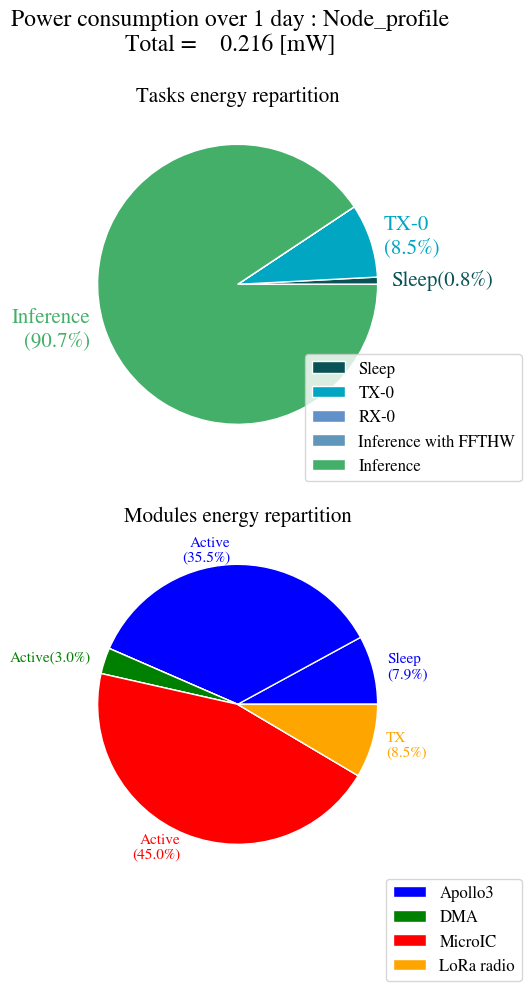

In [53]:
try:
    node.compute()
except Exception as e:
    print("An error occurred during the computation of the node profile:")
    print(e)
node.print_Tasks()
node.print_Modules()
node.plot_Power()

In [54]:
node.change_task_rate(Spectrogram_inference      ,0)
node.change_task_rate(FFTHW_Spectrogram_inference,0.9*Inference_p_day)

-------------------------------------------------
            Tasks summary                        
-------------------------------------------------
Task name            : Sleep          TX-0           RX-0           Inference with FFTHWInference      
Times/day    [1/d]   : 1              144            144            151875.0       0              
Tot. durat.  [s]     : 8585.5311      18.4689        36.0000        77760.0000     0.0000         
Tot. en./d   [mJ]    : 154.5396       1587.3989      0.6480         13125.6943     0.0000         
Node en./d   [mJ]    : 14868.2807      
Average pow. [mW]    : 0.1721          
-------------------------------------------------
-----------------------------------------------------------------
                        Module summary                           
-----------------------------------------------------------------
Module       State        Active [s]   Energy [mJ]  Av. Cur.[uA]  
Apollo3                   1787.6735    4323.2623    27

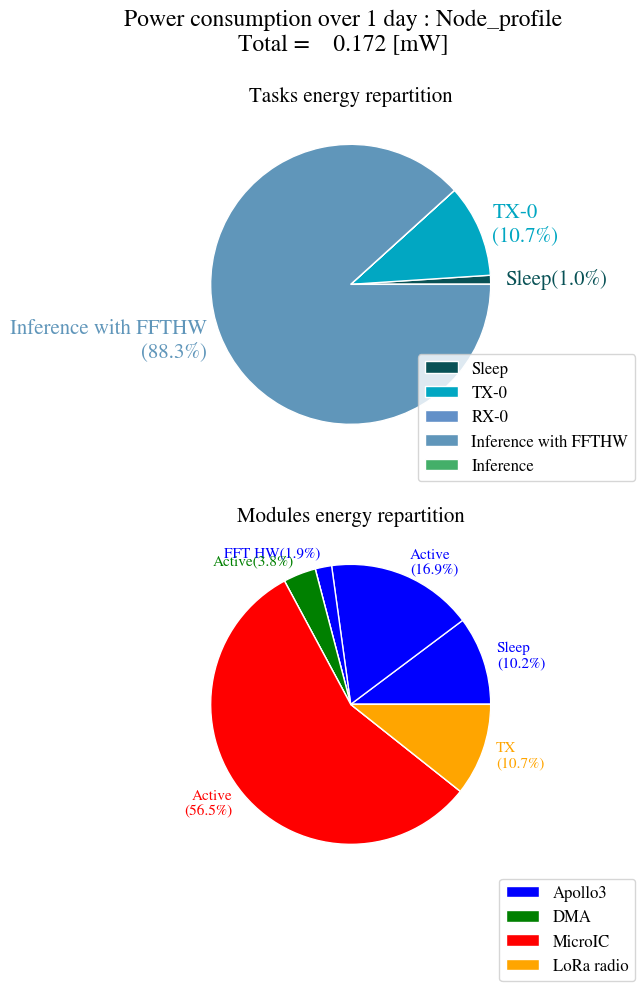

In [55]:
try:
    node.compute()
except Exception as e:
    print("An error occurred during the computation of the node profile:")
    print(e)
node.print_Tasks()
node.print_Modules()
node.plot_Power()

In [ ]:
show = 0

AA_series = 3
AA_footprint = 0.165
AA_cost      = 0.25 
Batt_footprint = AA_series*AA_footprint
Batt_cost      = AA_series*AA_cost

placementNnodes   = 100
decomNnodes       = 100
replacementNnodes = 10

transport_f =   transport_footprint(km_one_way = 10, 
                                    type ="Unit", 
                                    weight_g = 500,  
                                    footprint_p_tkm = 0.545,
                                    unit_factor = 1,
                                    footprint_p_km = 0.350)

transport_c =   transport_cost( worker = 1, salary_p_hour = 20, work_hour =0.3, km_p_h = 50,km_one_way = 10, 
                                type ="Unit", 
                                weight_g = 500, cost_p_tkm =  0.2/1e3,
                                unit_factor = 1,cost_p_km = 0.2)
    

node_footprint = Node_BoM(  casing            =[0.709,    0.3932, 1.3259], #709
                            connectivtiy      =[0.517,    0.2262, 0.5817],
                            eol               =[0.0812,   0.0388, 0.1201],
                            memory            =[0,        0,      0     ],
                            others            =[0.0938,   0.0546, 0.1394],
                            pcb               =[1.17,     0.9403, 1.5696], #1.17
                            power_supply      =[0.132,    0.0446, 0.1751],
                            processing        =[0.366,    0.3665, 0.4537],
                            sensing           =[0.0539,   0.0539, 0.5561],
                            ui                =[0.0306,   0.0017, 0.1155],
                            transport         =[transport_f*show,transport_f*show,transport_f*show],
                            battery           =[Batt_footprint  ,Batt_footprint,Batt_footprint],
                            placement         =[transport_f,transport_f,transport_f],
                            replacement       =[transport_f,transport_f,transport_f],
                            decom             =[transport_f,transport_f,transport_f], 
                            placementNnodes   = placementNnodes,
                            decomNnodes       = decomNnodes,
                            replacementNnodes = replacementNnodes)


node_Cost   = Node_BoM(     casing            =[10    ,    0 , 0], #ABS , IP rated
                            connectivtiy      =[5.3   ,    0 , 0], #SX1276 : 5.3
                            eol               =[0     ,    0 , 0],
                            memory            =[0     ,    0 , 0],
                            others            =[1.42  ,    0 , 0], #MLCC : 0.05*15 + XTAL32MHz: 0.5 + R: 0.002*15 + D : 0.07*2  
                            pcb               =[1.17  ,    0 , 0], #PCB 60cm2 : 1.75 
                            power_supply      =[0.228 ,    0 , 0], #XC6206 : 0.228 + Diode and Transistor?
                            processing        =[3.65  ,    0 , 0], #Apollo3: 3.65
                            sensing           =[6.94  ,    0 , 0], #BME680 : 6.94
                            ui                =[0.54  ,    0 , 0], #Push button : 0.17*2 + LED SMD : 0.2*1
                            transport         =[transport_c,0 , 0],
                            battery           =[Batt_cost  ,0 , 0],
                            placement         =[transport_c,0 , 0],
                            replacement       =[transport_c,0 , 0],
                            decom             =[transport_c,0 , 0],
                            placementNnodes   = 100,
                            decomNnodes       = 100,
                            replacementNnodes = 10)
